# テーマバスケット投資 × LSEG News：エンドツーエンド実装

このNotebookは、次の3つをJupyter Notebook上で完結させる実装です。

1. **ニュース取得**：`lseg.data`でRIC別ニュース、ニュース本文、価格データを取得する。
2. **テーマ抽出**：MST-kNNグラフ + 多解像度クラスタリングでニューステーマを抽出する。
3. **テーマの時間整列と投資シグナル化**：MSTML型の時間トピック整列を行い、MLSTM型の銘柄別・テーマ別インパクトモデルでテーマバスケットを構築する。

既定では `USE_LSEG = False` とし、LSEG環境がなくてもダミーデータで全パイプラインを動かせるようにしています。LSEG Workspace / Platformの権限がある環境では、設定セルで `USE_LSEG = True` に変更してください。

参照APIの要点：
- `ld.news.get_headlines()` はニュース見出しDataFrameを返し、`storyId` から `ld.news.get_story()` で本文を取得できます。
- 大量のheadline取得では、Content Layerの `news.headlines.Definition(...).get_data()` と `meta.next` cursor によるページングを使います。
- 価格履歴は `ld.get_history(universe=..., fields=..., interval=..., start=..., end=...)` を使います。

In [1]:
# ============================================================
# 0. Optional install
# ============================================================
# 初回のみ必要に応じて True にしてください。
INSTALL_PACKAGES = False

if INSTALL_PACKAGES:
    import sys, subprocess
    pkgs = [
        "numpy", "pandas", "scipy", "scikit-learn", "networkx", "matplotlib",
        "tqdm", "pyarrow", "statsmodels", "beautifulsoup4",
        # LSEG環境で実データ取得する場合
        "lseg-data",
        # 任意：Transformer埋め込みを使う場合。初回はモデルダウンロードが必要です。
        # "sentence-transformers",
    ]
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U"] + pkgs)

In [2]:
# ============================================================
# 1. Imports
# ============================================================
from __future__ import annotations

import os
# BLAS/OpenMPの過剰スレッドでNotebookが重くなるのを避ける
for _v in ["OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "VECLIB_MAXIMUM_THREADS", "NUMEXPR_NUM_THREADS"]:
    os.environ.setdefault(_v, "1")
import re
import json
import math
import time
import random
import warnings
from dataclasses import dataclass, asdict
from datetime import datetime, timedelta, time as dtime
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple, Any

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

from scipy import sparse
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.spatial.distance import pdist, squareform
from scipy.optimize import linear_sum_assignment
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.linalg import expm

import networkx as nx

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD, LatentDirichletAllocation
from sklearn.preprocessing import normalize
from sklearn.metrics import silhouette_score
from sklearn.linear_model import Ridge, RidgeCV

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 160)

/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# ============================================================
# 2. Configuration
# ============================================================
@dataclass
class PipelineConfig:
    # LSEGを使う場合 True。権限・Workspace/Platform設定が必要です。
    use_lseg: bool = False
    lseg_config_name: Optional[str] = None

    # 取得対象。日本株RICを混ぜる場合は例："6758.T", "7203.T", "9984.T"。
    rics: Tuple[str, ...] = (
        "NVDA.O", "MSFT.O", "AAPL.O", "AMZN.O", "TSLA.O",
        "META.O", "GOOGL.O", "AVGO.O", "AMD.O", "INTC.O",
        "6758.T", "7203.T", "9984.T"
    )
    benchmark_ric: Optional[str] = None  # Noneなら対象銘柄のクロスセクション平均をベンチマークにする

    # LSEG Newsは通常15か月程度の深度制限があるため、実データではこの範囲内にする。
    start: str = "2026-03-02"
    end: str = "2026-05-08"

    # News query
    language: str = "LEN"      # English
    source: Optional[str] = "RTRS"  # Reutersに絞る。Noneなら指定しない。
    page_size: int = 100
    max_pages_per_ric: Optional[int] = 5  # 本番では None。検証時は小さくする。
    max_stories: Optional[int] = 1500     # 本番では None。検証時は小さくする。
    request_throttle_sec: float = 0.35

    # Text / graph
    embedding_method: str = "tfidf_svd"  # "tfidf_svd" or "sentence_transformer"
    sentence_transformer_model: str = "sentence-transformers/all-MiniLM-L6-v2"
    tfidf_max_features: int = 5000
    svd_components: int = 32
    knn_k: int = 10
    markov_times: Tuple[float, ...] = (0.5, 1.0, 2.0, 4.0, 8.0)

    # Temporal topic alignment / MSTML-like
    temporal_freq: str = "M"       # "W", "M", "Q"
    temporal_n_topics: int = 8
    temporal_min_docs: int = 10
    lineage_distance_threshold: float = 0.45

    # Market target
    market_timezone: str = "Asia/Tokyo"
    market_close_time: str = "15:00"
    forward_horizon_days: int = 5
    exposure_lookback_days: int = 20
    exposure_half_life_days: float = 5.0

    # Alpha model
    ridge_alphas: Tuple[float, ...] = (0.01, 0.1, 1.0, 10.0, 100.0)
    alpha_group: float = 10.0
    alpha_ric: float = 25.0
    min_obs_per_group: int = 20

    # Basket
    long_top_n: int = 8
    short_top_n: int = 8
    long_short: bool = True
    max_abs_weight: float = 0.15

    # Output
    output_dir: str = "outputs_theme_basket"
    seed: int = 42

cfg = PipelineConfig()
Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)
random.seed(cfg.seed)
np.random.seed(cfg.seed)

asdict(cfg)

{'use_lseg': False,
 'lseg_config_name': None,
 'rics': ('NVDA.O',
  'MSFT.O',
  'AAPL.O',
  'AMZN.O',
  'TSLA.O',
  'META.O',
  'GOOGL.O',
  'AVGO.O',
  'AMD.O',
  'INTC.O',
  '6758.T',
  '7203.T',
  '9984.T'),
 'benchmark_ric': None,
 'start': '2026-03-02',
 'end': '2026-05-08',
 'language': 'LEN',
 'source': 'RTRS',
 'page_size': 100,
 'max_pages_per_ric': 5,
 'max_stories': 1500,
 'request_throttle_sec': 0.35,
 'embedding_method': 'tfidf_svd',
 'sentence_transformer_model': 'sentence-transformers/all-MiniLM-L6-v2',
 'tfidf_max_features': 5000,
 'svd_components': 32,
 'knn_k': 10,
 'markov_times': (0.5, 1.0, 2.0, 4.0, 8.0),
 'temporal_freq': 'M',
 'temporal_n_topics': 8,
 'temporal_min_docs': 10,
 'lineage_distance_threshold': 0.45,
 'market_timezone': 'Asia/Tokyo',
 'market_close_time': '15:00',
 'forward_horizon_days': 5,
 'exposure_lookback_days': 20,
 'exposure_half_life_days': 5.0,
 'ridge_alphas': (0.01, 0.1, 1.0, 10.0, 100.0),
 'alpha_group': 10.0,
 'alpha_ric': 25.0,
 'min_o

## 3. LSEG取得関数

`lseg.data` が利用可能な環境では、この節の関数でニュースと価格を取得します。Notebookの既定ではダミーデータを使うため、LSEGがない環境でも後続セルは動きます。

ニュースクエリはRICに対して `R:{RIC} AND Language:LEN AND Source:RTRS` の形式を基本にします。LSEGのニュースクエリ文法・エンタイトルメントにより利用可能なソースや件数は変わります。

In [4]:
# ============================================================
# 3. LSEG data access helpers
# ============================================================
def open_lseg_session(config_name: Optional[str] = None):
    """Open LSEG session and return imported lseg.data module."""
    try:
        import lseg.data as ld
    except Exception as e:
        raise RuntimeError(
            "lseg.data を import できません。LSEG環境で実行する場合は `pip install lseg-data` と設定ファイルを確認してください。"
        ) from e

    if config_name:
        ld.open_session(config_name=config_name)
    else:
        ld.open_session()
    return ld


def _extract_next_cursor(raw: Any) -> str:
    """Extract cursor from LSEG content-layer raw response."""
    if raw is None:
        return ""
    if isinstance(raw, list):
        for item in raw:
            if isinstance(item, dict):
                meta = item.get("meta", {})
                if isinstance(meta, dict) and meta.get("next"):
                    return meta.get("next") or ""
    if isinstance(raw, dict):
        meta = raw.get("meta", {})
        if isinstance(meta, dict):
            return meta.get("next") or ""
    return ""


def fetch_headlines_paginated(
    query: str,
    date_from: str,
    date_to: str,
    page_size: int = 100,
    max_pages: Optional[int] = None,
    throttle_sec: float = 0.35,
) -> pd.DataFrame:
    """
    Content Layerの cursor pagination でheadlineを取得する。
    1ページ最大100件が一般的な上限なので page_size は100を推奨。
    """
    from lseg.data.content import news

    frames: List[pd.DataFrame] = []
    cursor = ""
    page = 0

    while True:
        if cursor:
            definition = news.headlines.Definition(query="", extended_params={"cursor": cursor})
        else:
            definition = news.headlines.Definition(
                query=query,
                date_from=date_from,
                date_to=date_to,
                count=page_size,
            )

        response = definition.get_data()
        df = getattr(response.data, "df", None)
        if df is not None and not df.empty:
            df = df.copy()
            df["_query"] = query
            df["_page"] = page
            frames.append(df)

        raw = getattr(response.data, "raw", None)
        cursor = _extract_next_cursor(raw)
        page += 1

        if not cursor:
            break
        if max_pages is not None and page >= max_pages:
            break
        time.sleep(throttle_sec)

    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)


def make_news_query(ric: str, language: str = "LEN", source: Optional[str] = "RTRS") -> str:
    parts = [f"R:{ric}", f"Language:{language}"]
    if source:
        parts.append(f"Source:{source}")
    return " AND ".join(parts)


def fetch_lseg_news_for_rics(
    rics: Iterable[str],
    start: str,
    end: str,
    language: str = "LEN",
    source: Optional[str] = "RTRS",
    page_size: int = 100,
    max_pages_per_ric: Optional[int] = None,
    throttle_sec: float = 0.35,
) -> pd.DataFrame:
    all_frames = []
    for ric in tqdm(list(rics), desc="LSEG headlines by RIC"):
        query = make_news_query(ric, language=language, source=source)
        try:
            df = fetch_headlines_paginated(
                query=query,
                date_from=start,
                date_to=end,
                page_size=page_size,
                max_pages=max_pages_per_ric,
                throttle_sec=throttle_sec,
            )
            if not df.empty:
                df["queried_ric"] = ric
                all_frames.append(df)
        except Exception as e:
            print(f"[WARN] headline取得失敗: {ric} / {query} / {e}")
        time.sleep(throttle_sec)

    if not all_frames:
        return pd.DataFrame()
    return pd.concat(all_frames, ignore_index=True)


def pick_column(df: pd.DataFrame, candidates: List[str]) -> Optional[str]:
    if df is None or df.empty:
        return None
    lower_map = {str(c).lower(): c for c in df.columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    # loose match
    for cand in candidates:
        c0 = cand.lower().replace("_", "")
        for lc, orig in lower_map.items():
            if lc.replace("_", "") == c0:
                return orig
    return None


def fetch_lseg_stories(
    ld,
    story_ids: Iterable[str],
    max_stories: Optional[int] = None,
    throttle_sec: float = 0.35,
) -> pd.DataFrame:
    ids = pd.Series(list(story_ids)).dropna().astype(str).drop_duplicates().tolist()
    if max_stories is not None:
        ids = ids[:max_stories]

    records = []
    for sid in tqdm(ids, desc="LSEG stories"):
        text = None
        err = None
        try:
            fmt = getattr(ld.news.Format, "TEXT", None)
            if fmt is None:
                text = ld.news.get_story(sid)
            else:
                text = ld.news.get_story(sid, format=fmt)
        except Exception as e:
            err = str(e)
        records.append({"storyId": sid, "story_text": text, "story_error": err})
        time.sleep(throttle_sec)
    return pd.DataFrame(records)


def lseg_history_to_long(df: pd.DataFrame, universe: List[str]) -> pd.DataFrame:
    """Best-effort conversion of ld.get_history output to long format: date, ric, fields..."""
    if df is None or df.empty:
        return pd.DataFrame()

    out = df.copy()
    rset = set(map(str, universe))

    if isinstance(out.columns, pd.MultiIndex):
        lev0 = set(map(str, out.columns.get_level_values(0)))
        lev1 = set(map(str, out.columns.get_level_values(1))) if out.columns.nlevels > 1 else set()
        # RICがあるlevelをstackする
        if len(lev0 & rset) >= len(lev1 & rset):
            tmp = out.stack(0).reset_index()
            tmp = tmp.rename(columns={tmp.columns[0]: "date", tmp.columns[1]: "ric"})
        else:
            tmp = out.stack(1).reset_index()
            tmp = tmp.rename(columns={tmp.columns[0]: "date", tmp.columns[1]: "ric"})
        return tmp

    tmp = out.reset_index()
    date_col = pick_column(tmp, ["Date", "Datetime", "date", "index"])
    if date_col is None:
        date_col = tmp.columns[0]
    tmp = tmp.rename(columns={date_col: "date"})
    if len(universe) == 1:
        tmp["ric"] = universe[0]
    elif "Instrument" in tmp.columns:
        tmp = tmp.rename(columns={"Instrument": "ric"})
    return tmp


def fetch_lseg_price_history(
    ld,
    rics: Iterable[str],
    start: str,
    end: str,
    fields: Optional[List[str]] = None,
    interval: str = "1D",
    chunk_size: int = 20,
) -> pd.DataFrame:
    fields = fields or ["TRDPRC_1", "ACVOL_UNS"]
    rics = list(rics)
    frames = []
    for i in tqdm(range(0, len(rics), chunk_size), desc="LSEG history chunks"):
        chunk = rics[i:i + chunk_size]
        try:
            raw = ld.get_history(
                universe=chunk,
                fields=fields,
                interval=interval,
                start=start,
                end=end,
            )
            long = lseg_history_to_long(raw, chunk)
            frames.append(long)
        except Exception as e:
            print(f"[WARN] history取得失敗: {chunk} / {e}")
    if not frames:
        return pd.DataFrame()
    return pd.concat(frames, ignore_index=True)

## 4. ダミーデータ生成

LSEGに接続しない状態でも、ニューステーマ抽出からバスケット構築まで検証できます。実データ取得後も、このダミーデータの形に寄せておくと後続処理が安定します。

In [5]:
# ============================================================
# 4. Mock data generator
# ============================================================
def make_mock_theme_data(
    rics: Iterable[str],
    start: str,
    end: str,
    seed: int = 42,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    rng = np.random.default_rng(seed)
    rics = list(rics)
    dates = pd.bdate_range(start=start, end=end)

    sector_map = {}
    for ric in rics:
        if ric in {"NVDA.O", "AVGO.O", "AMD.O", "INTC.O"}:
            sector_map[ric] = "Semiconductors"
        elif ric in {"MSFT.O", "AAPL.O", "META.O", "GOOGL.O", "AMZN.O", "9984.T"}:
            sector_map[ric] = "Technology"
        elif ric in {"TSLA.O", "7203.T"}:
            sector_map[ric] = "Autos"
        elif ric in {"6758.T"}:
            sector_map[ric] = "Electronics"
        else:
            sector_map[ric] = "Other"

    theme_words = {
        "ai_semiconductors": ["ai", "gpu", "accelerator", "hbm", "chip", "datacenter", "inference", "cuda"],
        "cloud_capex": ["cloud", "capex", "server", "datacenter", "azure", "aws", "compute", "capacity"],
        "ev_battery": ["ev", "battery", "lithium", "charging", "range", "solid state", "vehicle", "hybrid"],
        "supply_chain": ["supply chain", "export controls", "tariff", "inventory", "shipment", "supplier", "china"],
        "rates_macro": ["rates", "fed", "yield", "inflation", "dollar", "macro", "policy"],
        "regulation_antitrust": ["regulation", "antitrust", "privacy", "fine", "probe", "commission", "compliance"],
    }
    themes = list(theme_words.keys())

    # 銘柄別テーマインパクト。mockでは「本当のbeta」を入れて、モデルが拾えるか確認する。
    beta = pd.DataFrame(
        rng.normal(0.0, 0.006, size=(len(rics), len(themes))),
        index=rics,
        columns=themes,
    )
    for ric in rics:
        if sector_map[ric] == "Semiconductors":
            beta.loc[ric, "ai_semiconductors"] += 0.012
            beta.loc[ric, "supply_chain"] -= 0.006
        if sector_map[ric] == "Technology":
            beta.loc[ric, "cloud_capex"] += 0.008
            beta.loc[ric, "regulation_antitrust"] -= 0.007
        if sector_map[ric] == "Autos":
            beta.loc[ric, "ev_battery"] += 0.010
            beta.loc[ric, "rates_macro"] -= 0.004

    # News
    names = {ric: ric.split(".")[0] for ric in rics}
    rows = []
    story_counter = 0
    for date in dates:
        for ric in rics:
            # 1日あたり平均0.25本程度
            n = rng.poisson(0.25)
            for _ in range(n):
                if sector_map[ric] == "Semiconductors":
                    probs = np.array([0.35, 0.20, 0.03, 0.18, 0.14, 0.10])
                elif sector_map[ric] == "Technology":
                    probs = np.array([0.18, 0.30, 0.03, 0.12, 0.12, 0.25])
                elif sector_map[ric] == "Autos":
                    probs = np.array([0.04, 0.05, 0.50, 0.14, 0.17, 0.10])
                else:
                    probs = np.ones(len(themes)) / len(themes)
                probs = probs / probs.sum()
                theme = rng.choice(themes, p=probs)
                words = rng.choice(theme_words[theme], size=5, replace=True)
                tone_word = rng.choice(["surges", "falls", "expands", "warns", "plans", "faces", "raises", "cuts"])
                headline = f"{names[ric]} {tone_word} on {' '.join(words[:3])}"
                body = (
                    f"{names[ric]} related news discusses {' '.join(words)}. "
                    f"Analysts focus on {theme.replace('_', ' ')} and potential earnings impact. "
                    f"Market participants cite demand, margins, guidance and policy risk."
                )
                timestamp = pd.Timestamp(date) + pd.Timedelta(
                    hours=int(rng.integers(7, 20)),
                    minutes=int(rng.integers(0, 60)),
                )
                rows.append({
                    "storyId": f"MOCK:{story_counter:07d}",
                    "versionCreated": timestamp,
                    "headline": headline,
                    "story_text": body,
                    "sourceCode": "MOCK",
                    "queried_ric": ric,
                    "true_theme": theme,
                })
                story_counter += 1

    news_df = pd.DataFrame(rows)

    # Exposure from true theme to generate returns
    if news_df.empty:
        raise RuntimeError("Mock news generation produced no rows; extend date range.")
    news_df["event_date"] = pd.to_datetime(news_df["versionCreated"]).dt.normalize()
    exp = (
        news_df.assign(exposure=1.0)
        .groupby(["queried_ric", "event_date", "true_theme"], as_index=False)["exposure"].sum()
    )

    # Prices: returns are driven by previous-day exposure plus market/noise
    market = pd.Series(rng.normal(0, 0.008, len(dates)), index=dates, name="market_ret")
    price_rows = []
    for ric in rics:
        px = 100.0 * np.exp(rng.normal(0, 0.05))
        for date in dates:
            prev = date - pd.tseries.offsets.BDay(1)
            e = exp[(exp["queried_ric"] == ric) & (exp["event_date"] == prev)]
            alpha = 0.0
            for _, row in e.iterrows():
                alpha += beta.loc[ric, row["true_theme"]] * row["exposure"]
            ret = 0.75 * market.loc[date] + alpha + rng.normal(0, 0.012)
            px *= (1 + ret)
            vol = int(np.exp(rng.normal(14, 0.4)) * (1 + min(abs(alpha) * 20, 1.5)))
            price_rows.append({"date": date, "ric": ric, "price": px, "volume": vol})

    prices_df = pd.DataFrame(price_rows)
    ref_df = pd.DataFrame({"ric": list(sector_map.keys()), "sector": list(sector_map.values())})
    ref_df = ref_df.merge(beta.reset_index().rename(columns={"index": "ric"}), on="ric", how="left")
    return news_df, prices_df, ref_df

## 5. データ取得またはダミーデータロード

LSEG実データを使う場合：
1. `cfg.use_lseg = True` にする。
2. `cfg.rics`, `cfg.start`, `cfg.end`, `cfg.source`, `cfg.max_pages_per_ric` を調整する。
3. LSEG WorkspaceまたはPlatform sessionの設定を済ませる。

In [6]:
# ============================================================
# 5. Load data
# ============================================================
if cfg.use_lseg:
    ld = open_lseg_session(cfg.lseg_config_name)

    headlines = fetch_lseg_news_for_rics(
        rics=cfg.rics,
        start=cfg.start,
        end=cfg.end,
        language=cfg.language,
        source=cfg.source,
        page_size=cfg.page_size,
        max_pages_per_ric=cfg.max_pages_per_ric,
        throttle_sec=cfg.request_throttle_sec,
    )
    print("headlines:", headlines.shape)
    display(headlines.head())

    story_col = pick_column(headlines, ["storyId", "storyID", "story_id"])
    if story_col is None:
        raise ValueError("headline DataFrameにstoryId列が見つかりません。columnsを確認してください。")

    stories = fetch_lseg_stories(
        ld=ld,
        story_ids=headlines[story_col],
        max_stories=cfg.max_stories,
        throttle_sec=cfg.request_throttle_sec,
    )
    news_df = headlines.merge(stories, left_on=story_col, right_on="storyId", how="left", suffixes=("", "_story"))

    raw_prices = fetch_lseg_price_history(
        ld=ld,
        rics=cfg.rics,
        start=cfg.start,
        end=cfg.end,
        fields=["TRDPRC_1", "ACVOL_UNS"],
        interval="1D",
    )
    prices_df = raw_prices.copy()

    # 実務では sector等は ld.get_data / PermID / TRBC などから取得する。
    ref_df = pd.DataFrame({"ric": list(cfg.rics), "sector": "Unknown"})
else:
    news_df, prices_df, ref_df = make_mock_theme_data(cfg.rics, cfg.start, cfg.end, seed=cfg.seed)

print("news_df", news_df.shape)
print("prices_df", prices_df.shape)
print("ref_df", ref_df.shape)
display(news_df.head())
display(prices_df.head())
display(ref_df.head())

news_df (180, 8)
prices_df (650, 4)
ref_df (13, 8)


,storyId,versionCreated,headline,story_text,sourceCode,queried_ric,true_theme,event_date
0,MOCK:0000000,2026-03-02 16:09:00,AAPL warns on ai ai inference,AAPL related news discusses ai ai inference da...,MOCK,AAPL.O,ai_semiconductors,2026-03-02
1,MOCK:0000001,2026-03-03 17:26:00,NVDA faces on inference cuda accelerator,NVDA related news discusses inference cuda acc...,MOCK,NVDA.O,ai_semiconductors,2026-03-03
2,MOCK:0000002,2026-03-03 16:12:00,NVDA warns on ai ai hbm,NVDA related news discusses ai ai hbm cuda gpu...,MOCK,NVDA.O,ai_semiconductors,2026-03-03
3,MOCK:0000003,2026-03-03 08:38:00,TSLA plans on shipment inventory tariff,TSLA related news discusses shipment inventory...,MOCK,TSLA.O,supply_chain,2026-03-03
4,MOCK:0000004,2026-03-04 12:28:00,MSFT cuts on azure azure server,MSFT related news discusses azure azure server...,MOCK,MSFT.O,cloud_capex,2026-03-04


,date,ric,price,volume
0,2026-03-02,NVDA.O,105.911530,1083458
1,2026-03-03,NVDA.O,102.649583,1635884
2,2026-03-04,NVDA.O,108.723848,2417143
3,2026-03-05,NVDA.O,107.281733,1574609
4,2026-03-06,NVDA.O,109.919443,2863915


,ric,sector,ai_semiconductors,cloud_capex,ev_battery,supply_chain,rates_macro,regulation_antitrust
0,NVDA.O,Semiconductors,0.013828,-0.006240,0.004503,-0.000357,-0.011706,-0.007813
1,MSFT.O,Technology,0.000767,0.006103,-0.000101,-0.005118,0.005276,-0.002333
2,AAPL.O,Technology,0.000396,0.014763,0.002805,-0.005156,0.002213,-0.012753
3,AMZN.O,Technology,0.005271,0.007700,-0.001109,-0.004086,0.007335,-0.007927
4,TSLA.O,Autos,-0.002570,-0.002113,0.013194,0.002193,-0.001524,0.002585


## 6. 前処理：列名、本文、時刻、イベント日

ニュース時刻は投資シグナル化のために営業日へ写像します。ここでは簡易的に、指定市場タイムゾーンで引け後ニュースを翌営業日にロールします。実運用では取引所カレンダー・祝日・半日取引を `exchange_calendars` 等で置換してください。

In [7]:
# ============================================================
# 6. Preprocessing
# ============================================================
def strip_html(text: Any) -> str:
    if text is None or (isinstance(text, float) and np.isnan(text)):
        return ""
    text = str(text)
    if "<" in text and ">" in text:
        try:
            from bs4 import BeautifulSoup
            return BeautifulSoup(text, "html.parser").get_text(" ")
        except Exception:
            text = re.sub(r"<[^>]+>", " ", text)
    return text


def clean_text(text: Any) -> str:
    text = strip_html(text)
    text = text.replace("\n", " ").replace("\t", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text


def standardize_news_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    story_col = pick_column(df, ["storyId", "storyID", "story_id"])
    headline_col = pick_column(df, ["headline", "HeadLine", "text"])
    ts_col = pick_column(df, ["versionCreated", "firstCreated", "timestamp", "created", "date", "Date"])
    source_col = pick_column(df, ["sourceCode", "source", "Source"])
    ric_col = pick_column(df, ["queried_ric", "ric", "RIC", "instrument"])

    if story_col and story_col != "storyId":
        df = df.rename(columns={story_col: "storyId"})
    if headline_col and headline_col != "headline":
        df = df.rename(columns={headline_col: "headline"})
    if ts_col and ts_col != "timestamp":
        df = df.rename(columns={ts_col: "timestamp"})
    if source_col and source_col != "source":
        df = df.rename(columns={source_col: "source"})
    if ric_col and ric_col != "queried_ric":
        df = df.rename(columns={ric_col: "queried_ric"})

    if "story_text" not in df.columns:
        df["story_text"] = ""
    if "headline" not in df.columns:
        df["headline"] = ""
    if "timestamp" not in df.columns:
        raise ValueError("ニュース時刻列が見つかりません。versionCreated / timestamp 等を確認してください。")
    if "queried_ric" not in df.columns:
        raise ValueError("RIC列が見つかりません。RIC別取得時に queried_ric を付けてください。")

    df["headline"] = df["headline"].map(clean_text)
    df["story_text"] = df["story_text"].map(clean_text)
    df["article_text"] = (df["headline"].fillna("") + ". " + df["story_text"].fillna("")).map(clean_text)
    df = df[df["article_text"].str.len() > 10].copy()

    if "storyId" in df.columns:
        df = df.drop_duplicates(["storyId", "queried_ric"]).copy()
    else:
        df["storyId"] = [f"ROW:{i}" for i in range(len(df))]

    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
    df = df.dropna(subset=["timestamp"]).copy()
    df = df.reset_index(drop=True)
    df["row_id"] = df.index
    return df


def business_day_roll(ts: pd.Timestamp) -> pd.Timestamp:
    ts = pd.Timestamp(ts).normalize()
    if ts.weekday() >= 5:
        return ts + pd.tseries.offsets.BDay(1)
    return ts


def assign_event_date(
    timestamps: pd.Series,
    timezone: str = "Asia/Tokyo",
    close_time: str = "15:00",
) -> pd.Series:
    # LSEGはtimezone-aware文字列の場合がある。naiveならUTCとして扱う。
    s = pd.to_datetime(timestamps, errors="coerce", utc=True)
    local = s.dt.tz_convert(timezone).dt.tz_localize(None)
    hh, mm = [int(x) for x in close_time.split(":")]
    close = dtime(hh, mm)
    event = local.dt.normalize()
    after_close = local.dt.time >= close
    event = event.mask(after_close, event + pd.tseries.offsets.BDay(1))
    event = event.map(business_day_roll)
    return pd.to_datetime(event)

news_df = standardize_news_df(news_df)
news_df["event_date"] = assign_event_date(
    news_df["timestamp"],
    timezone=cfg.market_timezone,
    close_time=cfg.market_close_time,
)

print(news_df.shape)
display(news_df[["row_id", "queried_ric", "timestamp", "event_date", "headline", "article_text"]].head())

(180, 10)


,row_id,queried_ric,timestamp,event_date,headline,article_text
0,0,AAPL.O,2026-03-02 16:09:00,2026-03-03,AAPL warns on ai ai inference,AAPL warns on ai ai inference. AAPL related ne...
1,1,NVDA.O,2026-03-03 17:26:00,2026-03-04,NVDA faces on inference cuda accelerator,NVDA faces on inference cuda accelerator. NVDA...
2,2,NVDA.O,2026-03-03 16:12:00,2026-03-04,NVDA warns on ai ai hbm,NVDA warns on ai ai hbm. NVDA related news dis...
3,3,TSLA.O,2026-03-03 08:38:00,2026-03-04,TSLA plans on shipment inventory tariff,TSLA plans on shipment inventory tariff. TSLA ...
4,4,MSFT.O,2026-03-04 12:28:00,2026-03-05,MSFT cuts on azure azure server,MSFT cuts on azure azure server. MSFT related ...


## 7. 文書埋め込みとMST-kNNグラフ

ここが Altuncu et al. 型の中核です。

- 文書をベクトル化する。
- コサイン類似度で記事間距離を作る。
- MSTで全体連結性を確保し、kNNで局所近傍を追加する。
- MST-kNNグラフ上で多解像度クラスタリングを行う。

In [8]:
# ============================================================
# 7. Embeddings and MST-kNN graph
# ============================================================
def compute_text_embeddings(
    texts: Iterable[str],
    method: str = "tfidf_svd",
    tfidf_max_features: int = 20000,
    svd_components: int = 128,
    sentence_transformer_model: str = "sentence-transformers/all-MiniLM-L6-v2",
    seed: int = 42,
) -> Tuple[np.ndarray, Dict[str, Any]]:
    texts = [clean_text(t) for t in texts]
    if len(texts) < 2:
        raise ValueError("文書数が2未満です。")

    if method == "sentence_transformer":
        try:
            from sentence_transformers import SentenceTransformer
            model = SentenceTransformer(sentence_transformer_model)
            emb = model.encode(texts, show_progress_bar=True, convert_to_numpy=True, normalize_embeddings=True)
            return emb, {"method": method, "model": sentence_transformer_model}
        except Exception as e:
            print(f"[WARN] sentence_transformerが使えないため tfidf_svd にフォールバックします: {e}")

    vectorizer = TfidfVectorizer(
        max_features=tfidf_max_features,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2 if len(texts) >= 20 else 1,
        max_df=0.90,
        strip_accents="unicode",
    )
    X_tfidf = vectorizer.fit_transform(texts)
    n_comp = min(svd_components, max(2, min(X_tfidf.shape) - 1))
    if n_comp >= 2:
        svd = TruncatedSVD(n_components=n_comp, n_iter=5, random_state=seed)
        X = svd.fit_transform(X_tfidf)
        explained = float(np.sum(svd.explained_variance_ratio_))
    else:
        svd = None
        X = X_tfidf.toarray()
        explained = np.nan
    X = normalize(X)
    meta = {"method": "tfidf_svd", "vectorizer": vectorizer, "svd": svd, "explained_variance": explained}
    return X, meta


def build_mst_knn_graph(X: np.ndarray, k: int = 10, min_weight: float = 1e-6) -> nx.Graph:
    X = normalize(np.asarray(X))
    n = X.shape[0]
    if n < 2:
        raise ValueError("n must be >= 2")
    k_eff = min(k, n - 1)

    sim = np.clip(X @ X.T, -1.0, 1.0)
    np.fill_diagonal(sim, 0.0)
    dist = 1.0 - sim
    np.fill_diagonal(dist, 0.0)

    G = nx.Graph()
    G.add_nodes_from(range(n))

    mst = minimum_spanning_tree(dist).tocoo()
    for i, j, d in zip(mst.row, mst.col, mst.data):
        w = max(1.0 - float(d), min_weight)
        G.add_edge(int(i), int(j), weight=w, kind="mst")

    for i in range(n):
        nbrs = np.argsort(-sim[i])[:k_eff]
        for j in nbrs:
            if i == j:
                continue
            w = max(float(sim[i, j]), min_weight)
            if G.has_edge(i, int(j)):
                G[i][int(j)]["weight"] = max(G[i][int(j)]["weight"], w)
                G[i][int(j)]["kind"] = "mst_knn"
            else:
                G.add_edge(i, int(j), weight=w, kind="knn")

    return G

X_doc, embedding_meta = compute_text_embeddings(
    news_df["article_text"].tolist(),
    method=cfg.embedding_method,
    tfidf_max_features=cfg.tfidf_max_features,
    svd_components=cfg.svd_components,
    sentence_transformer_model=cfg.sentence_transformer_model,
    seed=cfg.seed,
)

G = build_mst_knn_graph(X_doc, k=cfg.knn_k)
print("Embedding:", X_doc.shape, "meta:", {k: v for k, v in embedding_meta.items() if k not in {"vectorizer", "svd"}})
print("Graph nodes/edges:", G.number_of_nodes(), G.number_of_edges(), "connected:", nx.is_connected(G))

Embedding: (180, 32) meta: {'method': 'tfidf_svd', 'explained_variance': 0.6003159124503856}
Graph nodes/edges: 180 1056 connected: True


## 8. 多解像度クラスタリングとMarkov Stability評価

厳密なMarkov Stability最適化は専用実装が必要ですが、このNotebookでは実務で扱いやすい近似として次を行います。

1. Markov time `t` ごとに `resolution ≈ 1/t` としてグラフモジュラリティを最適化する。
2. 得られた分割を、可能なサイズでは連続時間ランダムウォークのMarkov Stabilityで評価する。
3. silhouette、modularity、stabilityの合成スコアで中粒度テーマを選ぶ。

大きい `t` は粗いテーマ、小さい `t` は細かいテーマに対応します。

Selected Markov time: 1.0


,markov_time,resolution,n_clusters,modularity,silhouette,markov_stability,selection_score
0,0.5,2.000,8,0.649159,0.413768,0.828594,1.4
1,1.0,1.000,6,0.818551,0.465585,0.819146,1.9
2,2.0,0.500,6,0.906546,0.465585,0.814912,1.9
3,4.0,0.250,6,0.950543,0.465585,0.807052,1.9
4,8.0,0.125,6,0.972541,0.465585,0.792107,1.9


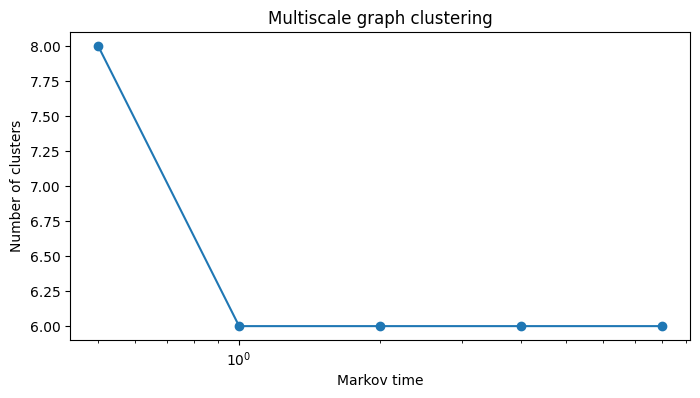

In [9]:
# ============================================================
# 8. Multiscale clustering + Markov Stability scoring
# ============================================================
def partition_to_labels(partition: Iterable[Iterable[int]], n: int) -> np.ndarray:
    labels = np.empty(n, dtype=int)
    for c, nodes in enumerate(partition):
        for node in nodes:
            labels[int(node)] = c
    return labels


def communities_from_labels(labels: np.ndarray) -> List[set]:
    return [set(np.where(labels == lab)[0].tolist()) for lab in sorted(np.unique(labels))]


def markov_stability_score(G: nx.Graph, labels: np.ndarray, t: float, max_exact_n: int = 200) -> float:
    """Continuous-time Markov Stability: trace(H' [Pi exp(-tLrw) - pi pi'] H)."""
    n = G.number_of_nodes()
    if n > max_exact_n:
        return np.nan
    A = nx.to_numpy_array(G, weight="weight", dtype=float)
    deg = A.sum(axis=1)
    if np.any(deg <= 0):
        return np.nan
    pi = deg / deg.sum()
    P = A / deg[:, None]
    Lrw = np.eye(n) - P
    Pt = expm(-t * Lrw)
    S = np.diag(pi) @ Pt - np.outer(pi, pi)
    score = 0.0
    for lab in np.unique(labels):
        idx = np.where(labels == lab)[0]
        score += S[np.ix_(idx, idx)].sum()
    return float(score)


def louvain_or_greedy(G: nx.Graph, resolution: float, seed: int = 42) -> List[set]:
    try:
        from networkx.algorithms.community import louvain_communities
        return louvain_communities(G, weight="weight", resolution=resolution, seed=seed)
    except Exception:
        from networkx.algorithms.community import greedy_modularity_communities
        return list(greedy_modularity_communities(G, weight="weight", resolution=resolution))


def run_multiscale_clustering(
    G: nx.Graph,
    X: np.ndarray,
    markov_times: Iterable[float],
    seed: int = 42,
) -> Tuple[pd.DataFrame, Dict[float, np.ndarray]]:
    records = []
    labels_by_t: Dict[float, np.ndarray] = {}
    n = G.number_of_nodes()

    for t in markov_times:
        # Markov timeが大きいほど粗い分割になるよう、resolutionを逆数で近似。
        resolution = max(0.05, 1.0 / float(t))
        partition = louvain_or_greedy(G, resolution=resolution, seed=seed)
        labels = partition_to_labels(partition, n)
        labels_by_t[float(t)] = labels
        n_clusters = int(len(np.unique(labels)))

        communities = communities_from_labels(labels)
        try:
            modularity = nx.algorithms.community.quality.modularity(
                G, communities, weight="weight", resolution=resolution
            )
        except Exception:
            modularity = np.nan

        if 1 < n_clusters < n:
            try:
                sil = silhouette_score(X, labels, metric="cosine")
            except Exception:
                sil = np.nan
        else:
            sil = np.nan

        stab = markov_stability_score(G, labels, t=float(t))
        records.append({
            "markov_time": float(t),
            "resolution": resolution,
            "n_clusters": n_clusters,
            "modularity": modularity,
            "silhouette": sil,
            "markov_stability": stab,
        })

    res = pd.DataFrame(records)
    # 合成スコア。各指標をrank化し、極端なNaNを避ける。
    score = pd.Series(0.0, index=res.index)
    for col in ["modularity", "silhouette", "markov_stability"]:
        if res[col].notna().sum() > 1:
            score += res[col].rank(pct=True)
    # 単一クラスタ・全孤立に近い分割を軽くペナルティ
    score -= (res["n_clusters"] <= 1).astype(float)
    score -= (res["n_clusters"] >= max(2, n // 2)).astype(float) * 0.25
    res["selection_score"] = score
    return res, labels_by_t

cluster_grid, labels_by_t = run_multiscale_clustering(
    G=G,
    X=X_doc,
    markov_times=cfg.markov_times,
    seed=cfg.seed,
)

best_t = float(cluster_grid.sort_values("selection_score", ascending=False).iloc[0]["markov_time"])
news_df["graph_theme_id"] = labels_by_t[best_t]

print("Selected Markov time:", best_t)
display(cluster_grid.sort_values("markov_time"))

plt.figure(figsize=(8, 4))
plt.plot(cluster_grid["markov_time"], cluster_grid["n_clusters"], marker="o")
plt.xscale("log")
plt.xlabel("Markov time")
plt.ylabel("Number of clusters")
plt.title("Multiscale graph clustering")
plt.show()

## 9. テーマの自動ラベリング

クラスタごとの上位TF-IDF語と代表headlineを確認します。ここでは機械的なラベル候補を出すだけです。投資運用では、この候補をもとに人手で「投資テーマ名」を付けるほうが安定します。

In [10]:
# ============================================================
# 9. Cluster summaries
# ============================================================
def summarize_clusters(
    df: pd.DataFrame,
    label_col: str,
    text_col: str = "article_text",
    headline_col: str = "headline",
    top_n_terms: int = 12,
    top_n_headlines: int = 3,
) -> pd.DataFrame:
    texts = df[text_col].fillna("").tolist()
    vectorizer = TfidfVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=1,
        max_features=15000,
        strip_accents="unicode",
    )
    X = vectorizer.fit_transform(texts)
    vocab = np.array(vectorizer.get_feature_names_out())

    rows = []
    for lab in sorted(df[label_col].dropna().unique()):
        mask = (df[label_col] == lab).values
        if mask.sum() == 0:
            continue
        mean_vec = np.asarray(X[mask].mean(axis=0)).ravel()
        top_idx = np.argsort(-mean_vec)[:top_n_terms]
        terms = [vocab[i] for i in top_idx if mean_vec[i] > 0]
        sample_heads = df.loc[mask, headline_col].dropna().head(top_n_headlines).tolist()
        rows.append({
            "theme_id": int(lab) if str(lab).isdigit() else lab,
            "n_articles": int(mask.sum()),
            "n_rics": int(df.loc[mask, "queried_ric"].nunique()) if "queried_ric" in df.columns else np.nan,
            "top_terms": ", ".join(terms),
            "sample_headlines": " | ".join(sample_heads),
        })
    return pd.DataFrame(rows).sort_values("n_articles", ascending=False)

cluster_summary = summarize_clusters(news_df, "graph_theme_id")
display(cluster_summary)

,theme_id,n_articles,n_rics,top_terms,sample_headlines
3,3,41,11,"ai, inference, chip, hbm, gpu, cuda, semicondu...",AAPL warns on ai ai inference | NVDA faces on ...
1,1,39,10,"capex, cloud, aws, azure, capacity, compute, s...",MSFT cuts on azure azure server | GOOGL plans ...
2,2,34,12,"supply chain, supply, chain, supplier, china, ...",TSLA plans on shipment inventory tariff | AAPL...
4,4,27,11,"macro, rates, inflation, fed, yield, dollar, r...",TSLA expands on fed policy rates | AMZN cuts o...
5,5,22,9,"regulation, antitrust, commission, compliance,...",AVGO faces on fine regulation probe | 6758 rai...
0,0,17,8,"battery, ev, range, charging, lithium, vehicle...",AAPL plans on solid state charging charging | ...


## 10. MSTML型：時間チャンク別LDA + Hellinger距離によるトピック整列

ここでは、時間チャンクごとにLDAを推定し、トピック語分布をHellinger距離で比較して隣接期間のトピックを整列します。これにより、毎期クラスタIDが入れ替わる問題を緩和し、テーマの系譜 `lineage_id` を作ります。

Temporal LDA by period:   0%|          | 0/3 [00:00<?, ?it/s]

Temporal LDA by period:  33%|███▎      | 1/3 [00:00<00:00,  2.27it/s]

Temporal LDA by period:  67%|██████▋   | 2/3 [00:00<00:00,  2.77it/s]

Temporal LDA by period: 100%|██████████| 3/3 [00:00<00:00,  3.96it/s]

Temporal LDA by period: 100%|██████████| 3/3 [00:00<00:00,  3.44it/s]

,period,local_topic,topic_key,n_period_docs,top_terms,lineage_id,hier_cluster
0,2026-03,0,2026-03::T00,74,"rates, macro, dollar, rates macro, focus rates...",L000,4
1,2026-03,1,2026-03::T01,74,"regulation, inflation, antitrust, regulation a...",L001,4
2,2026-03,2,2026-03::T02,74,"azure, capacity, export, export controls, cont...",L002,1
3,2026-03,3,2026-03::T03,74,"chain, supply, supply chain, china, supplier, ...",L003,2
4,2026-03,4,2026-03::T04,74,"ai, inference, commission, cuda, regulation, p...",L004,3
5,2026-03,5,2026-03::T05,74,"capex, azure, cloud, datacenter, cloud capex, ...",L005,1
6,2026-03,6,2026-03::T06,74,"capex, aws, capacity, cloud, googl, msft, aws ...",L006,1
7,2026-03,7,2026-03::T07,74,"inference, battery, ai, accelerator, chip, gpu...",L007,3
8,2026-04,0,2026-04::T00,78,"compliance antitrust, amzn, aapl, antitrust co...",L010,3
9,2026-04,1,2026-04::T01,78,"regulation, antitrust, compliance, inflation, ...",L009,4


,lineage_id,n_period_topics,periods,representative_terms
0,L005,2,"2026-03, 2026-04","capex, azure, cloud, datacenter, cloud capex, ..."
1,L003,2,"2026-03, 2026-04","chain, supply, supply chain, china, supplier, ..."
2,L010,2,"2026-04, 2026-05","compliance antitrust, amzn, aapl, antitrust co..."
3,L012,2,"2026-04, 2026-05","ai, datacenter, msft, cuda, datacenter cuda, a..."
4,L008,2,"2026-04, 2026-05","macro, yield, fed, rates, warns, macro potenti..."
5,L001,1,2026-03,"regulation, inflation, antitrust, regulation a..."
6,L004,1,2026-03,"ai, inference, commission, cuda, regulation, p..."
7,L002,1,2026-03,"azure, capacity, export, export controls, cont..."
8,L000,1,2026-03,"rates, macro, dollar, rates macro, focus rates..."
9,L006,1,2026-03,"capex, aws, capacity, cloud, googl, msft, aws ..."


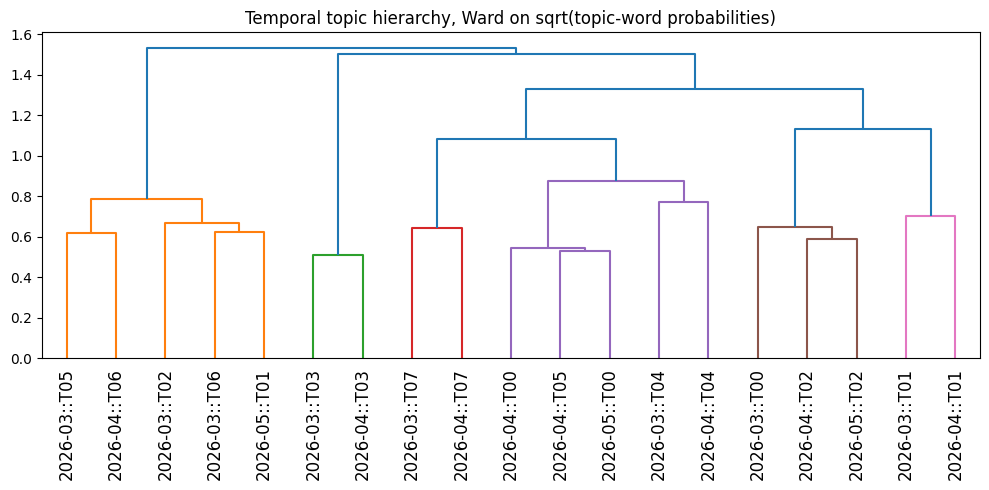

In [11]:
# ============================================================
# 10. Temporal topic alignment, MSTML-like
# ============================================================
def hellinger(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p = np.asarray(p, dtype=float) + eps
    q = np.asarray(q, dtype=float) + eps
    p = p / p.sum()
    q = q / q.sum()
    return float(np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q)) ** 2)) / np.sqrt(2.0))


def top_words_from_topic(topic: np.ndarray, vocab: np.ndarray, n: int = 12) -> str:
    idx = np.argsort(-topic)[:n]
    return ", ".join(vocab[idx])


def fit_temporal_lda(
    df: pd.DataFrame,
    text_col: str = "article_text",
    time_col: str = "event_date",
    freq: str = "M",
    n_topics: int = 8,
    min_docs: int = 10,
    seed: int = 42,
) -> Dict[str, Any]:
    df = df.copy()
    df["period"] = pd.to_datetime(df[time_col]).dt.to_period(freq).astype(str)

    vectorizer = CountVectorizer(
        stop_words="english",
        ngram_range=(1, 2),
        min_df=2 if len(df) >= 50 else 1,
        max_df=0.90,
        max_features=20000,
        strip_accents="unicode",
    )
    X_all = vectorizer.fit_transform(df[text_col].fillna(""))
    vocab = np.array(vectorizer.get_feature_names_out())

    topic_records = []
    doc_topic_rows = []
    topic_word: Dict[str, np.ndarray] = {}
    models: Dict[str, Any] = {}

    for period, g in tqdm(df.groupby("period", sort=True), desc="Temporal LDA by period"):
        idx = g.index.to_numpy()
        Xp = X_all[idx]
        n_docs = len(g)
        if n_docs < min_docs or Xp.shape[0] < 3:
            # 少数文書期間は1トピックに集約
            comp = np.asarray(Xp.sum(axis=0)).ravel() + 1e-9
            comp = comp / comp.sum()
            key = f"{period}::T00"
            topic_word[key] = comp
            topic_records.append({
                "period": period,
                "local_topic": 0,
                "topic_key": key,
                "n_period_docs": n_docs,
                "top_terms": top_words_from_topic(comp, vocab),
            })
            for row_id in g["row_id"].values:
                doc_topic_rows.append({"row_id": row_id, "period": period, "topic_key": key, "prob": 1.0})
            models[period] = {"model": None, "one_topic": True}
            continue

        k_eff = min(n_topics, max(2, n_docs // 8))
        k_eff = min(k_eff, max(2, Xp.shape[0] - 1))
        lda = LatentDirichletAllocation(
            n_components=k_eff,
            learning_method="batch",
            max_iter=30,
            random_state=seed,
            evaluate_every=-1,
        )
        doc_topic = lda.fit_transform(Xp)
        comps = lda.components_ + 1e-12
        comps = comps / comps.sum(axis=1, keepdims=True)

        models[period] = {"model": lda, "one_topic": False}
        for k in range(k_eff):
            key = f"{period}::T{k:02d}"
            topic_word[key] = comps[k]
            topic_records.append({
                "period": period,
                "local_topic": k,
                "topic_key": key,
                "n_period_docs": n_docs,
                "top_terms": top_words_from_topic(comps[k], vocab),
            })
        for row_id, probs in zip(g["row_id"].values, doc_topic):
            for k, prob in enumerate(probs):
                doc_topic_rows.append({
                    "row_id": row_id,
                    "period": period,
                    "topic_key": f"{period}::T{k:02d}",
                    "prob": float(prob),
                })

    topics_df = pd.DataFrame(topic_records)
    doc_topic_df = pd.DataFrame(doc_topic_rows)
    return {
        "topics_df": topics_df,
        "doc_topic_df": doc_topic_df,
        "topic_word": topic_word,
        "vectorizer": vectorizer,
        "vocab": vocab,
        "models": models,
    }


def align_topic_lineages(
    topics_df: pd.DataFrame,
    topic_word: Dict[str, np.ndarray],
    threshold: float = 0.45,
) -> pd.DataFrame:
    topics_df = topics_df.copy().sort_values(["period", "local_topic"]).reset_index(drop=True)
    periods = topics_df["period"].drop_duplicates().tolist()
    lineage_by_key: Dict[str, str] = {}
    next_lineage = 0

    prev_keys: List[str] = []
    for p_idx, period in enumerate(periods):
        cur_keys = topics_df.loc[topics_df["period"] == period, "topic_key"].tolist()
        if p_idx == 0 or not prev_keys:
            for key in cur_keys:
                lineage_by_key[key] = f"L{next_lineage:03d}"
                next_lineage += 1
            prev_keys = cur_keys
            continue

        C = np.zeros((len(prev_keys), len(cur_keys)))
        for i, pk in enumerate(prev_keys):
            for j, ck in enumerate(cur_keys):
                C[i, j] = hellinger(topic_word[pk], topic_word[ck])

        assigned_cur = set()
        rows, cols = linear_sum_assignment(C)
        for i, j in zip(rows, cols):
            ck = cur_keys[j]
            if C[i, j] <= threshold:
                lineage_by_key[ck] = lineage_by_key[prev_keys[i]]
            else:
                lineage_by_key[ck] = f"L{next_lineage:03d}"
                next_lineage += 1
            assigned_cur.add(ck)

        for ck in cur_keys:
            if ck not in assigned_cur:
                lineage_by_key[ck] = f"L{next_lineage:03d}"
                next_lineage += 1
        prev_keys = cur_keys

    topics_df["lineage_id"] = topics_df["topic_key"].map(lineage_by_key)
    return topics_df


def build_topic_hierarchy(topics_df: pd.DataFrame, topic_word: Dict[str, np.ndarray], max_clusters: int = 12):
    keys = topics_df["topic_key"].tolist()
    if len(keys) < 2:
        return None, pd.Series([1] * len(keys), index=keys)
    # Hellinger距離は sqrt(prob) 空間のEuclidean距離に対応するため、Ward linkageが使える。
    Xsqrt = np.vstack([np.sqrt(topic_word[k] / topic_word[k].sum()) for k in keys])
    Z = linkage(Xsqrt, method="ward")
    ncl = min(max_clusters, max(2, int(np.sqrt(len(keys)))))
    labels = fcluster(Z, t=ncl, criterion="maxclust")
    return Z, pd.Series(labels, index=keys)


temporal = fit_temporal_lda(
    news_df,
    text_col="article_text",
    time_col="event_date",
    freq=cfg.temporal_freq,
    n_topics=cfg.temporal_n_topics,
    min_docs=cfg.temporal_min_docs,
    seed=cfg.seed,
)

topics_df = align_topic_lineages(
    temporal["topics_df"],
    temporal["topic_word"],
    threshold=cfg.lineage_distance_threshold,
)
Z, hierarchy_labels = build_topic_hierarchy(topics_df, temporal["topic_word"])
topics_df["hier_cluster"] = topics_df["topic_key"].map(hierarchy_labels)

display(topics_df.head(30))

lineage_summary = (
    topics_df.groupby("lineage_id")
    .agg(
        n_period_topics=("topic_key", "count"),
        periods=("period", lambda x: ", ".join(map(str, sorted(set(x))))),
        representative_terms=("top_terms", lambda x: " || ".join(list(x)[:3])),
    )
    .sort_values("n_period_topics", ascending=False)
    .reset_index()
)
display(lineage_summary.head(20))

if Z is not None and len(topics_df) <= 80:
    plt.figure(figsize=(10, 5))
    dendrogram(Z, labels=topics_df["topic_key"].tolist(), leaf_rotation=90)
    plt.title("Temporal topic hierarchy, Ward on sqrt(topic-word probabilities)")
    plt.tight_layout()
    plt.show()

## 11. 記事ごとの安定テーマID付与

記事の期間内LDAトピック確率を、整列済み `lineage_id` に集約します。以降の投資モデルでは、グラフクラスタIDではなく、時間整列された `lineage_id` を基本テーマとして使います。

In [12]:
# ============================================================
# 11. Assign lineages to articles
# ============================================================
def assign_lineage_probabilities(
    news_df: pd.DataFrame,
    doc_topic_df: pd.DataFrame,
    topics_df: pd.DataFrame,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    topic_to_lineage = topics_df.set_index("topic_key")["lineage_id"].to_dict()
    dt = doc_topic_df.copy()
    dt["lineage_id"] = dt["topic_key"].map(topic_to_lineage)
    dt = dt.dropna(subset=["lineage_id"])
    lineage_probs = (
        dt.groupby(["row_id", "lineage_id"], as_index=False)["prob"].sum()
        .pivot(index="row_id", columns="lineage_id", values="prob")
        .fillna(0.0)
    )
    # normalize per article
    denom = lineage_probs.sum(axis=1).replace(0, np.nan)
    lineage_probs = lineage_probs.div(denom, axis=0).fillna(0.0)

    out = news_df.copy()
    aligned = lineage_probs.reindex(out["row_id"].values).fillna(0.0)
    out["temporal_theme_id"] = aligned.idxmax(axis=1).values
    out["temporal_theme_prob"] = aligned.max(axis=1).values
    return out, lineage_probs

news_df, lineage_probs = assign_lineage_probabilities(
    news_df,
    temporal["doc_topic_df"],
    topics_df,
)

print("Lineage probability matrix:", lineage_probs.shape)
display(news_df[["row_id", "queried_ric", "event_date", "headline", "graph_theme_id", "temporal_theme_id", "temporal_theme_prob"]].head())

Lineage probability matrix: (180, 14)


,row_id,queried_ric,event_date,headline,graph_theme_id,temporal_theme_id,temporal_theme_prob
0,0,AAPL.O,2026-03-03,AAPL warns on ai ai inference,3,L004,0.968738
1,1,NVDA.O,2026-03-04,NVDA faces on inference cuda accelerator,3,L007,0.514029
2,2,NVDA.O,2026-03-04,NVDA warns on ai ai hbm,3,L004,0.969815
3,3,TSLA.O,2026-03-04,TSLA plans on shipment inventory tariff,2,L003,0.620750
4,4,MSFT.O,2026-03-05,MSFT cuts on azure azure server,1,L005,0.577672


## 12. 市場データ前処理とターゲット作成

ターゲットは、テーマニュース後の将来リターンです。ここでは以下を使います。

- 各銘柄の日次リターン。
- ベンチマークは、指定がなければ対象ユニバースのクロスセクション平均リターン。
- 銘柄ごとにベンチマークbetaを推定し、残差リターンを作る。
- `h`営業日先までの累積残差リターンを教師データ `y` とする。

In [13]:
# ============================================================
# 12. Market target construction
# ============================================================
def standardize_price_df(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    # LSEG fields may come as TRDPRC_1 / ACVOL_UNS. Mock already has price / volume.
    date_col = pick_column(df, ["date", "Date", "Datetime", "timestamp"])
    ric_col = pick_column(df, ["ric", "RIC", "Instrument", "instrument"])
    price_col = pick_column(df, ["price", "TRDPRC_1", "Close", "CLOSE", "TR.PriceClose", "TR.CLOSEPRICE"])
    volume_col = pick_column(df, ["volume", "ACVOL_UNS", "Volume", "VOLUME", "TR.Volume"])

    if date_col and date_col != "date":
        df = df.rename(columns={date_col: "date"})
    if ric_col and ric_col != "ric":
        df = df.rename(columns={ric_col: "ric"})
    if price_col and price_col != "price":
        df = df.rename(columns={price_col: "price"})
    if volume_col and volume_col != "volume":
        df = df.rename(columns={volume_col: "volume"})

    required = {"date", "ric", "price"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"prices_dfに必要列がありません: {missing}. columns={list(df.columns)}")

    if "volume" not in df.columns:
        df["volume"] = np.nan

    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    df["price"] = pd.to_numeric(df["price"], errors="coerce")
    df["volume"] = pd.to_numeric(df["volume"], errors="coerce")
    df = df.dropna(subset=["date", "ric", "price"]).sort_values(["ric", "date"])
    return df


def forward_cum_return(ret: pd.Series, h: int) -> pd.Series:
    return (1.0 + ret).rolling(h).apply(np.prod, raw=True).shift(-h) - 1.0


def compute_targets(
    prices: pd.DataFrame,
    benchmark_ric: Optional[str] = None,
    horizon: int = 5,
) -> pd.DataFrame:
    px = standardize_price_df(prices)
    px = px.sort_values(["ric", "date"]).copy()
    px["ret"] = px.groupby("ric")["price"].pct_change()

    if benchmark_ric is not None and benchmark_ric in set(px["ric"]):
        bench = px.loc[px["ric"] == benchmark_ric, ["date", "ret"]].rename(columns={"ret": "bench_ret"})
    else:
        bench = px.groupby("date", as_index=False)["ret"].mean().rename(columns={"ret": "bench_ret"})
    px = px.merge(bench, on="date", how="left")

    # Full-sample beta estimate. 本番ではrolling betaに置換可能。
    beta_map = {}
    for ric, g in px.dropna(subset=["ret", "bench_ret"]).groupby("ric"):
        x = g["bench_ret"].values
        y = g["ret"].values
        var = np.var(x)
        beta_map[ric] = float(np.cov(x, y)[0, 1] / var) if var > 1e-12 else 1.0
    px["beta"] = px["ric"].map(beta_map).fillna(1.0)
    px["resid_ret"] = px["ret"] - px["beta"] * px["bench_ret"]
    px["y_fwd_resid_ret"] = px.groupby("ric")["resid_ret"].transform(lambda s: forward_cum_return(s, horizon))

    if px["volume"].notna().any():
        logv = np.log(px["volume"].replace(0, np.nan))
        px["log_volume"] = logv
        px["abn_volume_z"] = px.groupby("ric")["log_volume"].transform(
            lambda s: (s - s.rolling(20, min_periods=5).mean()) / s.rolling(20, min_periods=5).std()
        )
    else:
        px["abn_volume_z"] = np.nan

    return px

targets_df = compute_targets(prices_df, benchmark_ric=cfg.benchmark_ric, horizon=cfg.forward_horizon_days)
display(targets_df.head())

,date,ric,price,volume,ret,bench_ret,beta,resid_ret,y_fwd_resid_ret,log_volume,abn_volume_z
0,2026-03-02,6758.T,108.458006,3261085,NaN,NaN,0.87165,NaN,0.022474,14.997571,NaN
1,2026-03-03,6758.T,106.669617,1780258,-0.016489,-0.008326,0.87165,-0.009232,0.029131,14.392269,NaN
2,2026-03-04,6758.T,109.710063,807520,0.028503,0.023011,0.87165,0.008446,0.025606,13.601723,NaN
3,2026-03-05,6758.T,110.062332,1151972,0.003211,-0.003049,0.87165,0.005868,0.012247,13.956986,NaN
4,2026-03-06,6758.T,110.842020,1318847,0.007084,0.003341,0.87165,0.004172,-0.002310,14.092268,-0.220867


## 13. テーマ露出行列

記事ごとの `lineage_id` 確率を、RIC × event_date × theme に集約します。直近テーマバスケットではlookback windowと指数減衰を使い、過去数日のニュースをスコアに残します。

In [14]:
# ============================================================
# 13. Theme exposure matrix
# ============================================================
def build_theme_exposure(
    news_df: pd.DataFrame,
    lineage_probs: pd.DataFrame,
    ric_col: str = "queried_ric",
    date_col: str = "event_date",
    story_weight_col: Optional[str] = None,
) -> pd.DataFrame:
    base = news_df[["row_id", ric_col, date_col]].copy()
    base = base.rename(columns={ric_col: "ric", date_col: "date"})
    base["date"] = pd.to_datetime(base["date"]).dt.normalize()

    lp = lineage_probs.copy()
    lp.index.name = "row_id"
    long = lp.reset_index().melt(id_vars="row_id", var_name="theme_id", value_name="prob")
    long = long[long["prob"] > 1e-8].copy()
    long = long.merge(base, on="row_id", how="inner")

    if story_weight_col is not None and story_weight_col in news_df.columns:
        w = news_df[["row_id", story_weight_col]].rename(columns={story_weight_col: "story_weight"})
        long = long.merge(w, on="row_id", how="left")
        long["story_weight"] = pd.to_numeric(long["story_weight"], errors="coerce").fillna(1.0)
    else:
        long["story_weight"] = 1.0

    long["exposure"] = long["prob"] * long["story_weight"]
    exposure = (
        long.groupby(["ric", "date", "theme_id"], as_index=False)["exposure"].sum()
        .sort_values(["ric", "date", "theme_id"])
    )
    return exposure


def exposure_to_wide(exposure: pd.DataFrame, prefix: str = "theme") -> pd.DataFrame:
    wide = exposure.pivot_table(
        index=["ric", "date"],
        columns="theme_id",
        values="exposure",
        aggfunc="sum",
        fill_value=0.0,
    ).reset_index()
    theme_cols = [c for c in wide.columns if c not in {"ric", "date"}]
    rename = {c: f"{prefix}_{str(c)}" for c in theme_cols}
    wide = wide.rename(columns=rename)
    return wide

exposure_df = build_theme_exposure(news_df, lineage_probs)
exposure_wide = exposure_to_wide(exposure_df)
print(exposure_df.shape, exposure_wide.shape)
display(exposure_df.head())
display(exposure_wide.head())

(1137, 4) (159, 16)


,ric,date,theme_id,exposure
0,6758.T,2026-03-09,L000,0.004809
1,6758.T,2026-03-09,L001,0.004812
2,6758.T,2026-03-09,L002,0.004809
3,6758.T,2026-03-09,L003,0.004812
4,6758.T,2026-03-09,L004,0.966330


theme_id,ric,date,theme_L000,theme_L001,theme_L002,theme_L003,theme_L004,theme_L005,theme_L006,theme_L007,theme_L008,theme_L009,theme_L010,theme_L011,theme_L012,theme_L013
0,6758.T,2026-03-09,0.004809,0.004812,0.004809,0.004812,0.966330,0.004811,0.004808,0.004810,0.0,0.0,0.0,0.0,0.0,0.0
1,6758.T,2026-03-12,0.008908,0.219466,0.008922,0.666986,0.172590,0.905299,0.008920,0.008908,0.0,0.0,0.0,0.0,0.0,0.0
2,6758.T,2026-03-18,0.004464,0.004464,0.004464,0.968748,0.004465,0.004465,0.004464,0.004464,0.0,0.0,0.0,0.0,0.0,0.0
3,6758.T,2026-03-23,0.005209,0.005208,0.005208,0.338440,0.005211,0.005212,0.005208,0.630304,0.0,0.0,0.0,0.0,0.0,0.0
4,6758.T,2026-03-31,0.004808,0.004808,0.004811,0.004811,0.256156,0.714987,0.004811,0.004808,0.0,0.0,0.0,0.0,0.0,0.0


## 14. MLSTM型の教師ありモデル：階層Ridge近似

MLSTMの実務実装では、ニューストピック・ラベル・複数銘柄の市場反応を同時に扱うのが理想です。このNotebookでは、LSEGデータで動かしやすい近似として次を実装します。

- 説明変数：RIC × 日付のテーマ露出。
- 教師データ：将来 `h` 日累積の残差リターン。
- グローバルテーマbetaをRidgeで推定。
- セクター別・銘柄別の偏差betaをRidge shrinkageで推定。

これは「銘柄別ランダム効果付き教師ありトピックモデル」の投資シグナル部分を、安定したパネル回帰として切り出したものです。

In [15]:
# ============================================================
# 14. Hierarchical supervised alpha model
# ============================================================
def make_model_panel(
    targets: pd.DataFrame,
    exposure_wide: pd.DataFrame,
    ref_df: Optional[pd.DataFrame] = None,
    y_col: str = "y_fwd_resid_ret",
) -> Tuple[pd.DataFrame, List[str]]:
    t = targets[["ric", "date", y_col, "ret", "resid_ret", "abn_volume_z"]].copy()
    t["date"] = pd.to_datetime(t["date"]).dt.normalize()
    x = exposure_wide.copy()
    x["date"] = pd.to_datetime(x["date"]).dt.normalize()
    panel = t.merge(x, on=["ric", "date"], how="left")
    theme_cols = [c for c in panel.columns if str(c).startswith("theme_")]
    panel[theme_cols] = panel[theme_cols].fillna(0.0)

    if ref_df is not None and "ric" in ref_df.columns:
        keep = ["ric"] + [c for c in ["sector", "industry", "country"] if c in ref_df.columns]
        panel = panel.merge(ref_df[keep].drop_duplicates("ric"), on="ric", how="left")
    if "sector" not in panel.columns:
        panel["sector"] = "Unknown"
    panel["sector"] = panel["sector"].fillna("Unknown")

    panel = panel.dropna(subset=[y_col]).copy()
    return panel, theme_cols


def fit_hierarchical_ridge(
    panel: pd.DataFrame,
    theme_cols: List[str],
    y_col: str = "y_fwd_resid_ret",
    ric_col: str = "ric",
    sector_col: str = "sector",
    ridge_alphas: Iterable[float] = (0.01, 0.1, 1.0, 10.0, 100.0),
    alpha_group: float = 10.0,
    alpha_ric: float = 25.0,
    min_obs_per_group: int = 20,
) -> Dict[str, Any]:
    data = panel.dropna(subset=[y_col]).copy()
    X = data[theme_cols].astype(float).values
    y = data[y_col].astype(float).values

    global_model = RidgeCV(alphas=list(ridge_alphas), fit_intercept=True)
    global_model.fit(X, y)
    yhat_global = global_model.predict(X)
    resid = y - yhat_global

    sector_dev: Dict[str, np.ndarray] = {}
    sector_pred = np.zeros_like(y)
    if sector_col in data.columns:
        for sector, idx in data.groupby(sector_col).groups.items():
            idx = np.array(list(idx))
            loc = data.index.get_indexer(idx)
            loc = loc[loc >= 0]
            if len(loc) >= min_obs_per_group:
                m = Ridge(alpha=alpha_group, fit_intercept=False)
                m.fit(X[loc], resid[loc])
                coef = m.coef_.copy()
            else:
                coef = np.zeros(len(theme_cols))
            sector_dev[str(sector)] = coef
            sector_pred[loc] = X[loc] @ coef

    resid2 = resid - sector_pred

    ric_dev: Dict[str, np.ndarray] = {}
    for ric, idx in data.groupby(ric_col).groups.items():
        idx = np.array(list(idx))
        loc = data.index.get_indexer(idx)
        loc = loc[loc >= 0]
        if len(loc) >= min_obs_per_group:
            m = Ridge(alpha=alpha_ric, fit_intercept=False)
            m.fit(X[loc], resid2[loc])
            coef = m.coef_.copy()
        else:
            coef = np.zeros(len(theme_cols))
        ric_dev[str(ric)] = coef

    model = {
        "theme_cols": theme_cols,
        "global_intercept": float(global_model.intercept_),
        "global_beta": pd.Series(global_model.coef_, index=theme_cols),
        "global_alpha": float(getattr(global_model, "alpha_", np.nan)),
        "sector_dev": sector_dev,
        "ric_dev": ric_dev,
        "sector_col": sector_col,
        "ric_col": ric_col,
        "y_col": y_col,
    }

    # In-sample diagnostics
    pred = predict_panel(model, data, ref_df=None)
    model["in_sample_corr"] = float(pd.Series(pred).corr(pd.Series(y))) if np.std(pred) > 0 else np.nan
    model["in_sample_rmse"] = float(np.sqrt(np.mean((pred - y) ** 2)))
    return model


def beta_for_ric(model: Dict[str, Any], ric: str, sector: str = "Unknown") -> pd.Series:
    beta = model["global_beta"].copy()
    sec_dev = model.get("sector_dev", {}).get(str(sector))
    ric_dev = model.get("ric_dev", {}).get(str(ric))
    if sec_dev is not None:
        beta += pd.Series(sec_dev, index=model["theme_cols"])
    if ric_dev is not None:
        beta += pd.Series(ric_dev, index=model["theme_cols"])
    return beta


def predict_panel(model: Dict[str, Any], panel: pd.DataFrame, ref_df: Optional[pd.DataFrame] = None) -> np.ndarray:
    X = panel[model["theme_cols"]].astype(float)
    preds = np.full(len(panel), model["global_intercept"], dtype=float)
    for i, (_, row) in enumerate(panel.iterrows()):
        ric = str(row.get("ric", ""))
        sector = str(row.get("sector", "Unknown"))
        b = beta_for_ric(model, ric=ric, sector=sector)
        preds[i] += float(np.dot(X.iloc[i].values, b.values))
    return preds

panel, theme_cols = make_model_panel(targets_df, exposure_wide, ref_df=ref_df)
print("panel", panel.shape, "n_theme_cols", len(theme_cols))

alpha_model = fit_hierarchical_ridge(
    panel=panel,
    theme_cols=theme_cols,
    y_col="y_fwd_resid_ret",
    ridge_alphas=cfg.ridge_alphas,
    alpha_group=cfg.alpha_group,
    alpha_ric=cfg.alpha_ric,
    min_obs_per_group=cfg.min_obs_per_group,
)

print("global alpha:", alpha_model["global_alpha"])
print("in-sample corr:", alpha_model["in_sample_corr"], "rmse:", alpha_model["in_sample_rmse"])

global_beta_df = alpha_model["global_beta"].sort_values(ascending=False).to_frame("global_beta")
display(global_beta_df)

panel (585, 21) n_theme_cols 14


global alpha:

 100.0
in-sample corr: 0.2967786298744518 rmse: 0.02613365920924765


,global_beta
theme_L011,0.000869
theme_L009,0.000433
theme_L001,0.000354
theme_L010,-0.000065
theme_L003,-0.000197
theme_L006,-0.000218
theme_L002,-0.000236
theme_L000,-0.000259
theme_L012,-0.000386
theme_L004,-0.000393


## 15. 直近テーマ露出とバスケット構築

スコアは以下です。

\[
Score_{i,t} = \sum_k Exposure_{i,k,t}^{lookback} \cdot \hat{\beta}_{i,k}
\]

`Exposure` はlookback期間内ニュースを半減期で減衰させて集計します。バスケットは上位銘柄をロング、下位銘柄をショートにします。

asof_date: 2026-05-08 00:00:00


,ric,theme_L000,theme_L001,theme_L002,theme_L003,theme_L004,theme_L005,theme_L006,theme_L007,theme_L008,theme_L009,theme_L010,theme_L011,theme_L012,theme_L013,sector,score,abs_exposure
0,AVGO.O,0.0,0.0,0.0,0.152568,0.0,0.245325,0.0,0.0,2.117438,0.003946,0.600522,0.434762,0.832652,0.043761,Semiconductors,0.004962,4.430973
1,INTC.O,0.0,0.0,0.0,0.095238,0.0,0.001123,0.0,0.0,0.036129,0.001122,0.973249,0.162594,0.016598,0.001122,Semiconductors,0.001237,1.287175
2,9984.T,0.0,0.0,0.0,0.001204,0.0,0.033694,0.0,0.0,0.030418,0.179868,0.001204,0.001204,0.001204,0.001204,Technology,0.000526,0.250000
3,AMD.O,0.0,0.0,0.0,0.001993,0.0,0.123892,0.0,0.0,0.001992,0.001993,0.001992,0.053644,0.001995,0.233687,Semiconductors,0.000282,0.421189
4,NVDA.O,0.0,0.0,0.0,0.051285,0.0,0.155893,0.0,0.0,0.001963,0.023233,0.001963,0.134326,0.001963,0.081488,Semiconductors,0.000176,0.452113
5,AAPL.O,0.0,0.0,0.0,0.160512,0.0,0.000907,0.0,0.0,0.000907,0.000907,0.051683,0.000907,0.000907,0.000907,Technology,-0.000400,0.217638
6,MSFT.O,0.0,0.0,0.0,0.001649,0.0,0.140106,0.0,0.0,0.983214,0.211225,0.023633,0.001649,0.657855,0.001649,Technology,-0.002173,2.020979
7,AMZN.O,0.0,0.0,0.0,0.000397,0.0,0.000397,0.0,0.0,0.028913,0.057487,0.780280,0.000397,1.502366,0.000397,Technology,-0.002420,2.370632
8,TSLA.O,0.0,0.0,0.0,0.025986,0.0,0.002431,0.0,0.0,1.552421,0.459387,1.614090,0.002431,0.043545,0.058400,Autos,-0.003296,3.758692
9,META.O,0.0,0.0,0.0,0.107366,0.0,0.106935,0.0,0.0,0.381090,0.139047,0.020583,0.002301,0.984160,0.107491,Technology,-0.003692,1.848973


,ric,sector,score,abs_exposure,side,weight
0,AVGO.O,Semiconductors,0.004962,4.430973,LONG,0.1000
1,INTC.O,Semiconductors,0.001237,1.287175,LONG,0.1000
2,9984.T,Technology,0.000526,0.250000,LONG,0.1000
3,AMD.O,Semiconductors,0.000282,0.421189,LONG,0.1000
4,NVDA.O,Semiconductors,0.000176,0.452113,LONG,0.1000
5,AAPL.O,Technology,-0.000400,0.217638,SHORT,-0.0625
6,MSFT.O,Technology,-0.002173,2.020979,SHORT,-0.0625
7,AMZN.O,Technology,-0.002420,2.370632,SHORT,-0.0625
8,TSLA.O,Autos,-0.003296,3.758692,SHORT,-0.0625
9,META.O,Technology,-0.003692,1.848973,SHORT,-0.0625


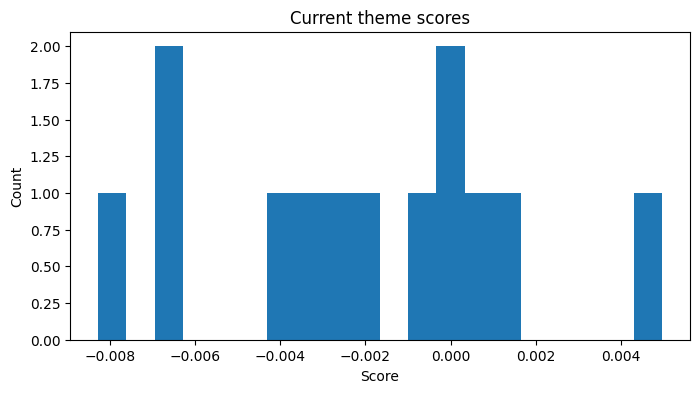

In [16]:
# ============================================================
# 15. Basket scoring and construction
# ============================================================
def current_exposure_wide(
    exposure: pd.DataFrame,
    asof_date: Optional[pd.Timestamp] = None,
    lookback_days: int = 20,
    half_life_days: float = 5.0,
    prefix: str = "theme",
) -> pd.DataFrame:
    exp = exposure.copy()
    exp["date"] = pd.to_datetime(exp["date"]).dt.normalize()
    if asof_date is None:
        asof_date = exp["date"].max()
    asof_date = pd.Timestamp(asof_date).normalize()
    start = asof_date - pd.Timedelta(days=lookback_days)
    sub = exp[(exp["date"] <= asof_date) & (exp["date"] >= start)].copy()
    if sub.empty:
        return pd.DataFrame(columns=["ric"])
    lam = math.log(2.0) / max(half_life_days, 1e-9)
    sub["days_ago"] = (asof_date - sub["date"]).dt.days.astype(float)
    sub["decay_weight"] = np.exp(-lam * sub["days_ago"])
    sub["decayed_exposure"] = sub["exposure"] * sub["decay_weight"]
    wide = sub.pivot_table(
        index="ric",
        columns="theme_id",
        values="decayed_exposure",
        aggfunc="sum",
        fill_value=0.0,
    ).reset_index()
    rename = {c: f"{prefix}_{str(c)}" for c in wide.columns if c != "ric"}
    return wide.rename(columns=rename)


def score_current_basket(
    exposure: pd.DataFrame,
    model: Dict[str, Any],
    ref_df: pd.DataFrame,
    asof_date: Optional[pd.Timestamp] = None,
    lookback_days: int = 20,
    half_life_days: float = 5.0,
) -> pd.DataFrame:
    cur = current_exposure_wide(
        exposure,
        asof_date=asof_date,
        lookback_days=lookback_days,
        half_life_days=half_life_days,
    )
    if cur.empty:
        return pd.DataFrame()

    for c in model["theme_cols"]:
        if c not in cur.columns:
            cur[c] = 0.0
    cur = cur[["ric"] + model["theme_cols"]]
    out = cur.merge(ref_df[["ric", "sector"]].drop_duplicates("ric"), on="ric", how="left") if "sector" in ref_df.columns else cur.copy()
    out["sector"] = out.get("sector", "Unknown")
    out["sector"] = out["sector"].fillna("Unknown")

    scores = []
    for _, row in out.iterrows():
        beta = beta_for_ric(model, ric=str(row["ric"]), sector=str(row["sector"]))
        x = row[model["theme_cols"]].astype(float)
        score = float(np.dot(x.values, beta.values))
        scores.append(score)
    out["score"] = scores
    out["abs_exposure"] = out[model["theme_cols"]].abs().sum(axis=1)
    out = out.sort_values("score", ascending=False).reset_index(drop=True)
    return out


def construct_basket(
    scores: pd.DataFrame,
    long_top_n: int = 10,
    short_top_n: int = 10,
    long_short: bool = True,
    max_abs_weight: float = 0.15,
    sector_neutral_score: bool = False,
) -> pd.DataFrame:
    df = scores.copy()
    if df.empty:
        return df
    score_col = "score"
    if sector_neutral_score and "sector" in df.columns:
        df["score_sector_neutral"] = df["score"] - df.groupby("sector")["score"].transform("mean")
        score_col = "score_sector_neutral"

    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)
    longs = df[df[score_col] > 0].head(long_top_n).copy()
    longs["side"] = "LONG"

    if long_short:
        shorts = df[df[score_col] < 0].tail(short_top_n).copy()
        shorts["side"] = "SHORT"
        if not longs.empty:
            longs["raw_weight"] = 0.5 / len(longs)
        if not shorts.empty:
            shorts["raw_weight"] = -0.5 / len(shorts)
        basket = pd.concat([longs, shorts], ignore_index=True)
        if basket.empty:
            return basket
        # 片側しかない場合はgross=1へ再正規化
        gross = basket["raw_weight"].abs().sum()
        basket["weight"] = basket["raw_weight"] / gross if gross > 0 else basket["raw_weight"]
    else:
        basket = longs.copy()
        if basket.empty:
            return basket
        basket["raw_weight"] = 1.0 / len(basket)
        basket["weight"] = basket["raw_weight"] / basket["raw_weight"].abs().sum()

    # cap and renormalize by gross exposure
    basket["weight"] = basket["weight"].clip(-max_abs_weight, max_abs_weight)
    gross = basket["weight"].abs().sum()
    if gross > 0:
        basket["weight"] = basket["weight"] / gross

    return basket.sort_values("weight", ascending=False).reset_index(drop=True)

asof_date = exposure_df["date"].max()
scores_df = score_current_basket(
    exposure=exposure_df,
    model=alpha_model,
    ref_df=ref_df,
    asof_date=asof_date,
    lookback_days=cfg.exposure_lookback_days,
    half_life_days=cfg.exposure_half_life_days,
)

basket_df = construct_basket(
    scores_df,
    long_top_n=cfg.long_top_n,
    short_top_n=cfg.short_top_n,
    long_short=cfg.long_short,
    max_abs_weight=cfg.max_abs_weight,
    sector_neutral_score=False,
)

print("asof_date:", asof_date)
display(scores_df.head(30))
display(basket_df[["ric", "sector", "score", "abs_exposure", "side", "weight"]])

plt.figure(figsize=(8, 4))
plt.hist(scores_df["score"].dropna(), bins=20)
plt.xlabel("Score")
plt.ylabel("Count")
plt.title("Current theme scores")
plt.show()

## 16. 検証・診断

実運用前に最低限見るべき診断です。

- どのテーマが多すぎるか、または1銘柄に偏りすぎていないか。
- テーマbetaが経済的に解釈できるか。
- バスケットがセクター・サイズ・流動性に偏っていないか。
- 日次・週次リバランス時のturnoverが過大でないか。

,theme_id,n_ric,n_days,total_exposure,theme_col,global_beta
0,L005,13,41,23.484227,theme_L005,-0.000480
1,L003,13,41,21.267526,theme_L003,-0.000197
2,L008,13,28,17.353747,theme_L008,-0.000605
3,L009,13,22,15.980120,theme_L009,0.000433
4,L011,13,22,15.166650,theme_L011,0.000869
5,L004,13,19,14.994657,theme_L004,-0.000393
6,L013,13,22,14.861118,theme_L013,-0.000564
7,L007,13,19,14.414267,theme_L007,-0.000454
8,L012,13,28,12.126177,theme_L012,-0.000386
9,L000,13,19,6.521332,theme_L000,-0.000259


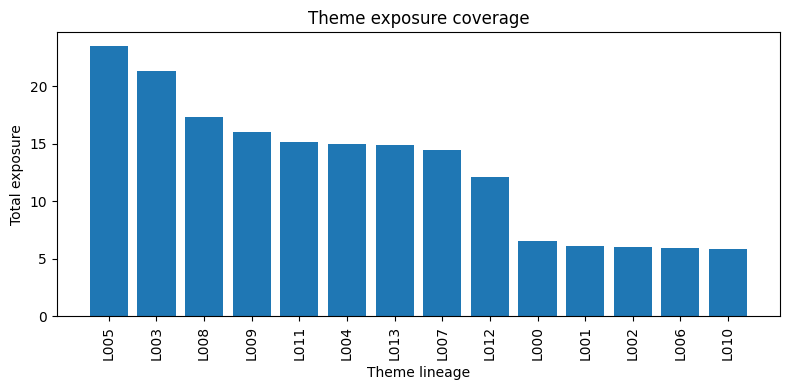

,sector,weight
2,Semiconductors,0.4000
1,Electronics,-0.0625
0,Autos,-0.1250
3,Technology,-0.2125


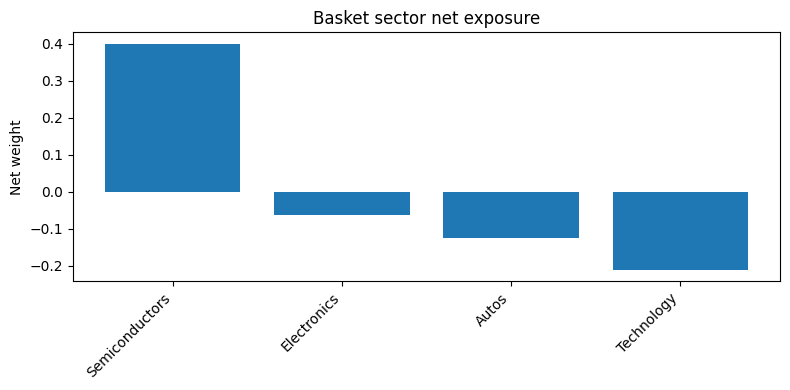

In [17]:
# ============================================================
# 16. Diagnostics
# ============================================================
# Theme coverage
coverage = (
    exposure_df.groupby("theme_id")
    .agg(
        n_ric=("ric", "nunique"),
        n_days=("date", "nunique"),
        total_exposure=("exposure", "sum"),
    )
    .sort_values("total_exposure", ascending=False)
    .reset_index()
)
coverage["theme_col"] = "theme_" + coverage["theme_id"].astype(str)
coverage = coverage.merge(
    global_beta_df.reset_index().rename(columns={"index": "theme_col"}),
    on="theme_col",
    how="left",
)
display(coverage)

plt.figure(figsize=(8, 4))
plt.bar(coverage["theme_id"].astype(str), coverage["total_exposure"])
plt.xticks(rotation=90)
plt.xlabel("Theme lineage")
plt.ylabel("Total exposure")
plt.title("Theme exposure coverage")
plt.tight_layout()
plt.show()

# Basket sector exposure
if not basket_df.empty and "sector" in basket_df.columns:
    sector_exposure = basket_df.groupby("sector", as_index=False)["weight"].sum().sort_values("weight", ascending=False)
    display(sector_exposure)
    plt.figure(figsize=(8, 4))
    plt.bar(sector_exposure["sector"], sector_exposure["weight"])
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Net weight")
    plt.title("Basket sector net exposure")
    plt.tight_layout()
    plt.show()

## 17. 出力保存

主要アウトプットをCSV/Parquetに保存します。

In [18]:

# ============================================================
# 17. Save outputs
# ============================================================
outdir = Path(cfg.output_dir)
outdir.mkdir(parents=True, exist_ok=True)

def save_table(df: pd.DataFrame, stem: str) -> None:
    """Parquetが使える環境ではparquet、なければCSVに保存する。"""
    try:
        df.to_parquet(outdir / f"{stem}.parquet", index=False)
    except Exception:
        df.to_csv(outdir / f"{stem}.csv", index=False)

save_table(news_df, "news_with_themes")
save_table(exposure_df, "theme_exposure")
topics_df.to_csv(outdir / "temporal_topics.csv", index=False)
cluster_summary.to_csv(outdir / "graph_cluster_summary.csv", index=False)
coverage.to_csv(outdir / "theme_coverage_and_beta.csv", index=False)
scores_df.to_csv(outdir / "current_scores.csv", index=False)
basket_df.to_csv(outdir / "theme_basket.csv", index=False)

model_export = {
    "config": asdict(cfg),
    "theme_cols": alpha_model["theme_cols"],
    "global_intercept": alpha_model["global_intercept"],
    "global_beta": alpha_model["global_beta"].to_dict(),
    "global_alpha": alpha_model["global_alpha"],
    "in_sample_corr": alpha_model["in_sample_corr"],
    "in_sample_rmse": alpha_model["in_sample_rmse"],
}
with open(outdir / "alpha_model_summary.json", "w", encoding="utf-8") as f:
    json.dump(model_export, f, ensure_ascii=False, indent=2, default=str)

print(f"Saved outputs to: {outdir.resolve()}")
print("Main output:", outdir / "theme_basket.csv")


Saved outputs to: /mnt/data/outputs_theme_basket
Main output: outputs_theme_basket/theme_basket.csv


## 18. 実データ運用時の拡張ポイント

このNotebookをそのままMVPとして使い、次の順で拡張してください。

1. **ニュース蓄積**：LSEG Newsは履歴深度制限があるため、日次でheadline/storyをParquetに保存する。
2. **関連RIC拡張**：`queried_ric` だけでなく、ニュース本文・メタデータ・MRN等から関連RICを抽出し、共起ネットワークを作る。
3. **テーマ辞書の人手レビュー**：自動ラベルをそのまま投資テーマにせず、運用者が上位語・代表記事・銘柄露出を見てテーマ名を確定する。
4. **取引所カレンダー**：`BDay` を正式な取引所カレンダーに置換する。
5. **リスクモデル連携**：sector/style/beta/FX/size/liquidity制約を最適化に入れる。
6. **ウォークフォワード検証**：モデル推定期間と投資期間を分離し、IC、hit ratio、turnover、capacityを確認する。